# Laboratorio 6 — Transfer Learning y Fine-Tuning

## 0. Configuración

In [1]:
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"torch {torch.__version__} | device: {device}")

torch 2.8.0 | device: mps


## 1. Dataset
CIFAR-10 con `torchvision`. Se cargan primero **sin transformaciones** (imágenes PIL) para explorar los datos crudos.

In [2]:
train_raw = datasets.CIFAR10(root="data", train=True, download=True)
test_raw = datasets.CIFAR10(root="data", train=False, download=True)

CLASSES = train_raw.classes
print(train_raw)
print(test_raw)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test


## 2. Exploración de los datos

### 2.1 Observaciones y balance de clases
> ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?

Observaciones de entrenamiento: 50,000
Observaciones de test:          10,000
Número de clases:               10


,clase,train,test,train_%,test_%
0,airplane,5000,1000,10.0,10.0
1,automobile,5000,1000,10.0,10.0
2,bird,5000,1000,10.0,10.0
3,cat,5000,1000,10.0,10.0
4,deer,5000,1000,10.0,10.0
5,dog,5000,1000,10.0,10.0
6,frog,5000,1000,10.0,10.0
7,horse,5000,1000,10.0,10.0
8,ship,5000,1000,10.0,10.0
9,truck,5000,1000,10.0,10.0


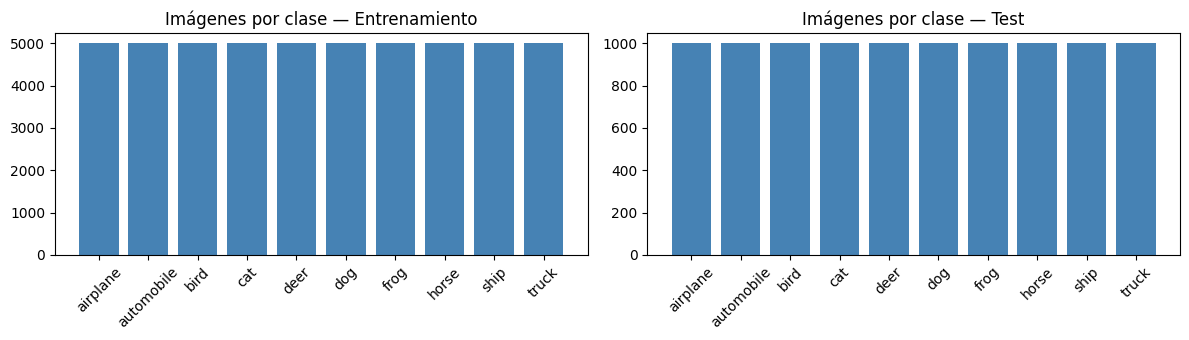

In [3]:
y_train = np.array(train_raw.targets)
y_test = np.array(test_raw.targets)

print(f"Observaciones de entrenamiento: {len(y_train):,}")
print(f"Observaciones de test:          {len(y_test):,}")
print(f"Número de clases:               {len(CLASSES)}")

conteo = pd.DataFrame({
    "clase": CLASSES,
    "train": np.bincount(y_train),
    "test": np.bincount(y_test),
})
conteo["train_%"] = (conteo["train"] / conteo["train"].sum() * 100).round(2)
conteo["test_%"] = (conteo["test"] / conteo["test"].sum() * 100).round(2)
display(conteo)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
for ax, col, titulo in zip(axes, ["train", "test"], ["Entrenamiento", "Test"]):
    ax.bar(conteo["clase"], conteo[col], color="steelblue")
    ax.set_title(f"Imágenes por clase — {titulo}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 2.2 Resolución, canales y estadísticas por canal
> ¿Cuál es la resolución y el número de canales? Calcule la media y desviación estándar por canal del conjunto de entrenamiento y compárelas con las de ImageNet.

In [4]:
# train_raw.data: array uint8 de forma (N, H, W, C)
X_train = train_raw.data
print(f"Forma del arreglo de entrenamiento: {X_train.shape}  dtype={X_train.dtype}")
N, H, W, C = X_train.shape
print(f"Resolución: {H}x{W} | Canales: {C} | Rango de píxeles: [{X_train.min()}, {X_train.max()}]")

# Media y desviación estándar por canal (escala [0, 1]) sobre TODO el conjunto de entrenamiento
X_float = X_train.astype(np.float64) / 255.0
CIFAR_MEAN = X_float.mean(axis=(0, 1, 2))
CIFAR_STD = X_float.std(axis=(0, 1, 2))
del X_float

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

stats = pd.DataFrame(
    {
        "CIFAR-10 media": CIFAR_MEAN,
        "ImageNet media": IMAGENET_MEAN,
        "Δ media": CIFAR_MEAN - IMAGENET_MEAN,
        "CIFAR-10 std": CIFAR_STD,
        "ImageNet std": IMAGENET_STD,
        "Δ std": CIFAR_STD - IMAGENET_STD,
    },
    index=["R", "G", "B"],
).round(4)
display(stats)

Forma del arreglo de entrenamiento: (50000, 32, 32, 3)  dtype=uint8
Resolución: 32x32 | Canales: 3 | Rango de píxeles: [0, 255]


,CIFAR-10 media,ImageNet media,Δ media,CIFAR-10 std,ImageNet std,Δ std
R,0.4914,0.485,0.0064,0.2470,0.229,0.0180
G,0.4822,0.456,0.0262,0.2435,0.224,0.0195
B,0.4465,0.406,0.0405,0.2616,0.225,0.0366


### 2.3 Visualización de ejemplos por clase
> Visualice al menos 5 ejemplos por clase. ¿Qué pares de clases esperan que sean más difíciles de distinguir y por qué?

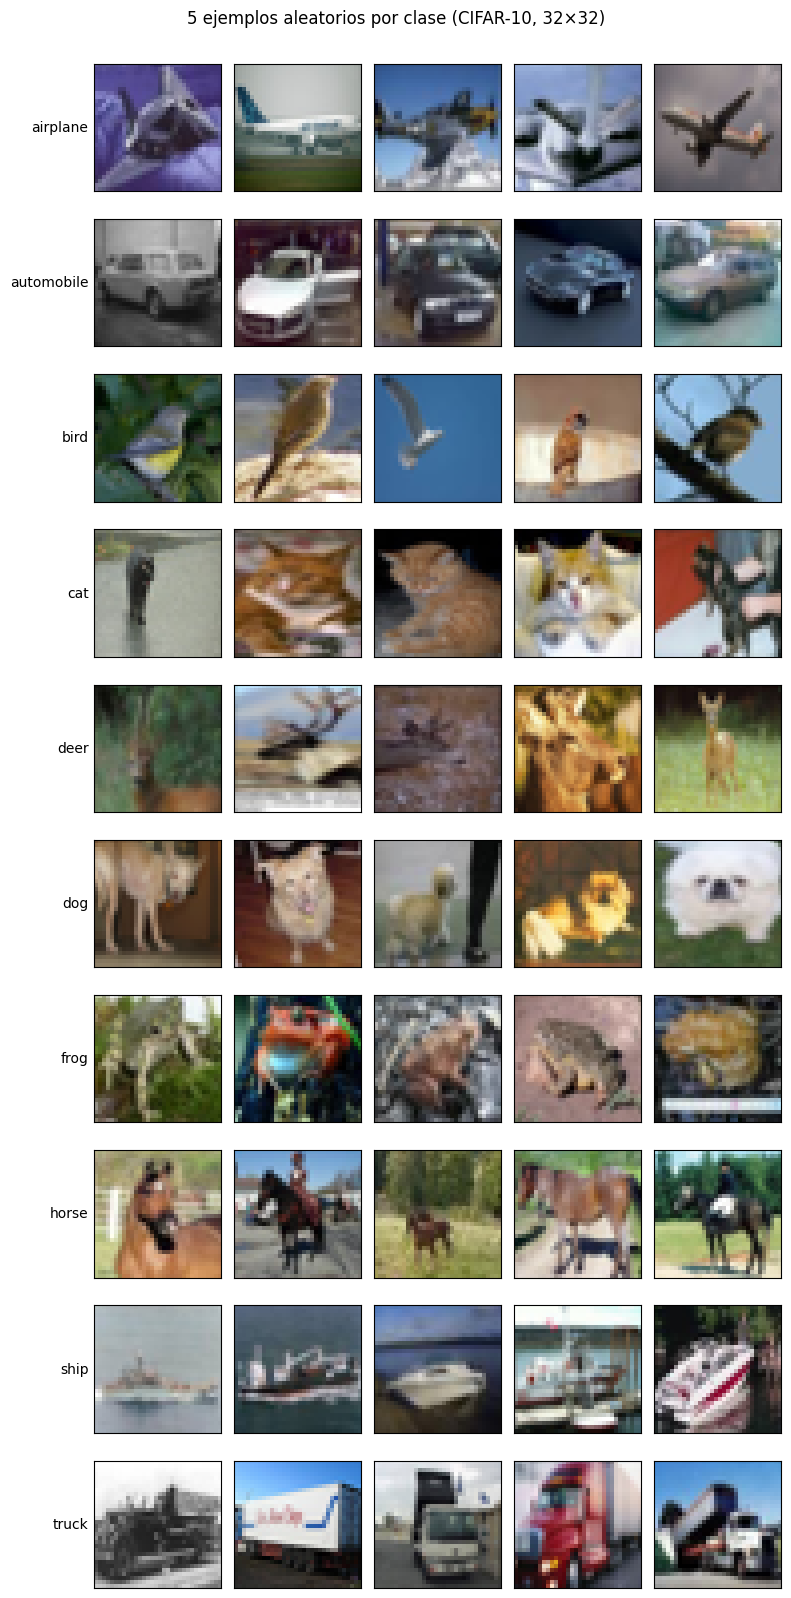

In [5]:
N_EJEMPLOS = 5
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(len(CLASSES), N_EJEMPLOS, figsize=(N_EJEMPLOS * 1.6, len(CLASSES) * 1.6))
for c, nombre in enumerate(CLASSES):
    idx = rng.choice(np.where(y_train == c)[0], N_EJEMPLOS, replace=False)
    for j, i in enumerate(idx):
        ax = axes[c, j]
        ax.imshow(train_raw.data[i])
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(nombre, rotation=0, ha="right", va="center", fontsize=10)
plt.suptitle("5 ejemplos aleatorios por clase (CIFAR-10, 32×32)", y=1.0)
plt.tight_layout()
plt.show()

### 2.4 Pipelines de preprocesamiento
> ¿Qué transformaciones de preprocesamiento necesita cada modelo? Defina un pipeline para la CNN desde cero (resolución nativa) y otro para VGG-16 (redimensionamiento y normalización de ImageNet). ¿Qué pasa con el número de píxeles, y por lo tanto con el cómputo, al pasar de 32×32 a 224×224?

In [6]:
VGG_RES = 128   # candidatos: 224 (estándar), 128, 112

# --- Evaluación (validación / test): sin aleatoriedad ---
# CNN desde cero: resolución nativa 32x32, normalizada con estadísticas de CIFAR-10
eval_tf_scratch = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN.tolist(), CIFAR_STD.tolist()),
])

# VGG-16: redimensionar + normalización de ImageNet (lo que espera el backbone preentrenado)
eval_tf_vgg = transforms.Compose([
    transforms.Resize((VGG_RES, VGG_RES)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN.tolist(), IMAGENET_STD.tolist()),
])

# Comparación de costo por imagen según la resolución
filas = []
for res in [32, 112, 128, 224]:
    px = res * res
    filas.append({"resolución": f"{res}x{res}", "píxeles/canal": px, "valores/imagen (x3)": px * 3,
                  "factor vs 32x32": round(px / (32 * 32), 1)})
display(pd.DataFrame(filas))

,resolución,píxeles/canal,valores/imagen (x3),factor vs 32x32
0,32x32,1024,3072,1.0
1,112x112,12544,37632,12.2
2,128x128,16384,49152,16.0
3,224x224,50176,150528,49.0


### 2.5 Data augmentation
> ¿Qué técnicas de data augmentation utilizarán y por qué? Justifique por qué la augmentation se aplica solo al conjunto de entrenamiento.

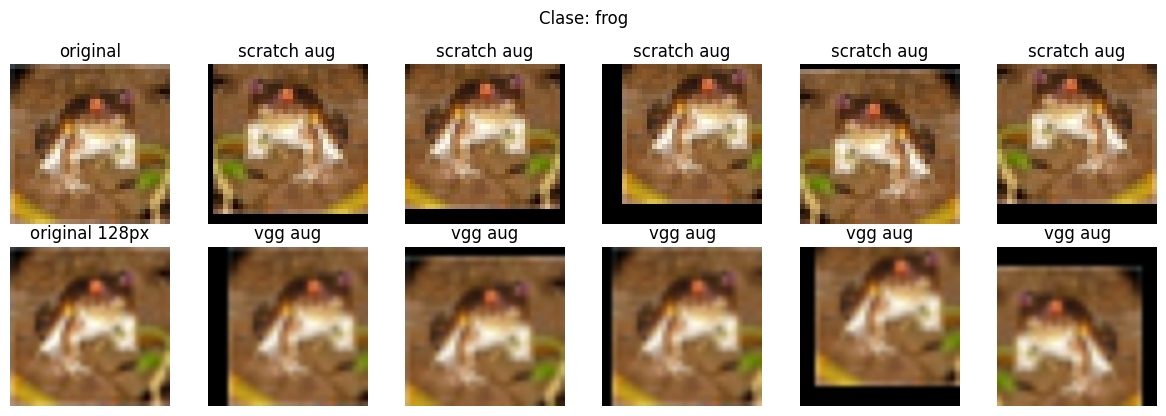

In [7]:
# Augmentation (solo entrenamiento): transformaciones que preservan la clase
# --- CNN desde cero ---
train_tf_scratch = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN.tolist(), CIFAR_STD.tolist()),
])

# --- VGG-16 (mismo augmentation en resolución nativa, luego resize + ImageNet) ---
train_tf_vgg = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((VGG_RES, VGG_RES)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN.tolist(), IMAGENET_STD.tolist()),
])

def desnormalizar(t, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Visualizar el efecto del augmentation sobre una misma imagen
img, etiqueta = train_raw[0]
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
axes[0, 0].imshow(img); axes[0, 0].set_title("original")
axes[1, 0].imshow(img.resize((VGG_RES, VGG_RES))); axes[1, 0].set_title(f"original {VGG_RES}px")
for j in range(1, 6):
    axes[0, j].imshow(desnormalizar(train_tf_scratch(img), CIFAR_MEAN, CIFAR_STD))
    axes[0, j].set_title("scratch aug")
    axes[1, j].imshow(desnormalizar(train_tf_vgg(img), IMAGENET_MEAN, IMAGENET_STD))
    axes[1, j].set_title("vgg aug")
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle(f"Clase: {CLASSES[etiqueta]}")
plt.tight_layout()
plt.show()

## 3. División entrenamiento / validación / test
Se divide el train original en **45,000 / 5,000 estratificado por clase**; el test oficial (10,000) se reserva para la evaluación final.

Se instancian **dos copias** del dataset de entrenamiento con distintas transformaciones (con y sin augmentation) y se indexan con los mismos índices, de modo que validación **no** reciba augmentation.

In [8]:
idx_all = np.arange(len(y_train))
idx_train, idx_val = train_test_split(
    idx_all, test_size=5_000, stratify=y_train, random_state=SEED
)

print(f"train: {len(idx_train):,} | val: {len(idx_val):,} | test: {len(y_test):,}")
print("Traslape train/val:", len(set(idx_train) & set(idx_val)))

balance = pd.DataFrame({
    "clase": CLASSES,
    "train": np.bincount(y_train[idx_train], minlength=10),
    "val": np.bincount(y_train[idx_val], minlength=10),
    "test": np.bincount(y_test, minlength=10),
})
display(balance)

# Guardar índices para reproducibilidad entre notebooks/corridas
np.savez("split_indices.npz", train=idx_train, val=idx_val)

train: 45,000 | val: 5,000 | test: 10,000
Traslape train/val: 0


,clase,train,val,test
0,airplane,4500,500,1000
1,automobile,4500,500,1000
2,bird,4500,500,1000
3,cat,4500,500,1000
4,deer,4500,500,1000
5,dog,4500,500,1000
6,frog,4500,500,1000
7,horse,4500,500,1000
8,ship,4500,500,1000
9,truck,4500,500,1000


### Subconjunto reducido para el experimento de la sección 4.1
10 % del set de entrenamiento (de los 45,000), estratificado por clase; validación y test no cambian.

In [9]:
FRACCION_REDUCIDA = 0.10
idx_train_small, _ = train_test_split(
    idx_train, train_size=FRACCION_REDUCIDA, stratify=y_train[idx_train], random_state=SEED
)
print(f"Subconjunto reducido: {len(idx_train_small):,} imágenes")
print("Por clase:", np.bincount(y_train[idx_train_small], minlength=10))
np.savez("split_indices.npz", train=idx_train, val=idx_val, train_small=idx_train_small)

Subconjunto reducido: 4,500 imágenes
Por clase: [450 450 450 450 450 450 450 450 450 450]


### Datasets y DataLoaders

In [10]:
def make_datasets(train_tf, eval_tf):
    # Copias del dataset con transformaciones distintas, indexadas con los mismos splits
    full_train_aug = datasets.CIFAR10("data", train=True, download=False, transform=train_tf)
    full_train_eval = datasets.CIFAR10("data", train=True, download=False, transform=eval_tf)
    test_ds = datasets.CIFAR10("data", train=False, download=False, transform=eval_tf)
    return {
        "train": Subset(full_train_aug, idx_train),
        "train_small": Subset(full_train_aug, idx_train_small),
        "val": Subset(full_train_eval, idx_val),
        "test": test_ds,
    }

def make_loaders(dsets, batch_size, num_workers=0):
    pin = device == "cuda"
    return {
        name: DataLoader(ds, batch_size=batch_size, shuffle=(name.startswith("train")),
                         num_workers=num_workers, pin_memory=pin)
        for name, ds in dsets.items()
    }

ds_scratch = make_datasets(train_tf_scratch, eval_tf_scratch)
ds_vgg = make_datasets(train_tf_vgg, eval_tf_vgg)

BATCH_SCRATCH = 128
BATCH_VGG = 64   # más pequeño: las entradas de VGG son mucho más grandes
dl_scratch = make_loaders(ds_scratch, BATCH_SCRATCH)
dl_vgg = make_loaders(ds_vgg, BATCH_VGG)

# Verificación rápida de formas
for nombre, dl in [("scratch", dl_scratch), ("vgg", dl_vgg)]:
    xb, yb = next(iter(dl["train"]))
    print(f"{nombre:8s} batch train: x={tuple(xb.shape)} y={tuple(yb.shape)} "
          f"| media≈{xb.mean():.3f} std≈{xb.std():.3f}")
    xv, _ = next(iter(dl["val"]))
    print(f"{'':8s} batch val:   x={tuple(xv.shape)}")

scratch  batch train: x=(128, 3, 32, 32) y=(128,) | media≈-0.252 std≈1.131
         batch val:   x=(128, 3, 32, 32)
vgg      batch train: x=(64, 3, 128, 128) y=(64,) | media≈-0.131 std≈1.295
         batch val:   x=(64, 3, 128, 128)


### Verificación de la normalización

In [11]:
def stats_loader(dl, max_batches=40):
    s, s2, n = torch.zeros(3), torch.zeros(3), 0
    for i, (x, _) in enumerate(dl):
        if i >= max_batches:
            break
        s += x.sum(dim=(0, 2, 3)); s2 += (x ** 2).sum(dim=(0, 2, 3)); n += x.numel() / 3
    m = s / n
    return m.numpy().round(3), (s2 / n - m ** 2).sqrt().numpy().round(3)

for nombre, dl in [("scratch (val)", dl_scratch["val"]), ("vgg (val)", dl_vgg["val"])]:
    m, sd = stats_loader(dl)
    print(f"{nombre:14s} media por canal={m} | std por canal={sd}")

scratch (val)  media por canal=[0.01  0.002 0.003] | std por canal=[1.006 1.002 0.999]


vgg (val)      media por canal=[0.038 0.117 0.184] | std por canal=[1.06  1.066 1.143]
